### Import packages

In [2]:
library(readxl)
library(ggfortify)
library(edgeR)
library(ggpubr)
library(ggrepel)
library(randomForest)
library(ggplotify)
library(RColorBrewer)
library(pROC)
library(data.table)


Loading required package: ggplot2

Loading required package: limma

randomForest 4.7-1.1

Type rfNews() to see new features/changes/bug fixes.


Attaching package: ‘randomForest’


The following object is masked from ‘package:ggplot2’:

    margin


Type 'citation("pROC")' for a citation.


Attaching package: ‘pROC’


The following objects are masked from ‘package:stats’:

    cov, smooth, var




### Read tables resulting from merging_datasets

In [3]:
scaled_df = read.csv('../data/merged_dataset.csv')
meta = read.csv('../data/merged_dataset_meta.csv')

In [11]:
m_became = scaled_df[meta[rownames(scaled_df),]$cohort=='BECAME',]
meta_became = meta[rownames(m_became),]
m_became_patients = m_became[rownames(meta_became[which(meta_became$group!='CONTROL'),]),]


m_miracle = scaled_df[meta[rownames(scaled_df),]$cohort=='MIRACLE',]
meta_miracle = meta[rownames(m_miracle),]
m_miracle_patients = m_miracle[rownames(meta_miracle[which(meta_miracle$group!='CONTROL'),]),]


In [12]:
m_became_patients=data.frame(m_became_patients)
m_became_patients$group = meta_became[rownames(m_became_patients),'cluster']
for(i in 1:(ncol(m_became_patients)-1)){
    m_became_patients[,i]=as.numeric(m_became_patients[,i])
}
m_became_patients$group = factor(m_became_patients$group)

### Train random forest to classify the became clusters in the became cohort with the first 70% of samples

In [13]:
set.seed(456)

m_became_patients$group = as.factor(gsub('B','',m_became_patients$group))

# Define your formula for classificatio7
formula <- group~.
keep = c(colnames(m_became_patients)[1:161],'group')
# Train the Random Forest classifier
rf_model_allClusters <- randomForest(formula, 
                         data = m_became_patients[1:round(nrow(m_became_patients)*.7),keep], 
                         ntree = 1000)



In [14]:
predictions_became <- predict(rf_model_allClusters, m_became_patients[round(nrow(m_became_patients)*.7):nrow(m_became_patients),], type = "response")
accuracy_became <- mean(predictions_became == m_became_patients[round(nrow(m_became_patients)*.7):nrow(m_became_patients),'group'])
cat("Accuracy:", accuracy_became, "\n")

predictions_miracle <- predict(rf_model_allClusters, m_miracle_patients, type = "response")

Accuracy: 0.96875 


### Generate Confusion Matrices

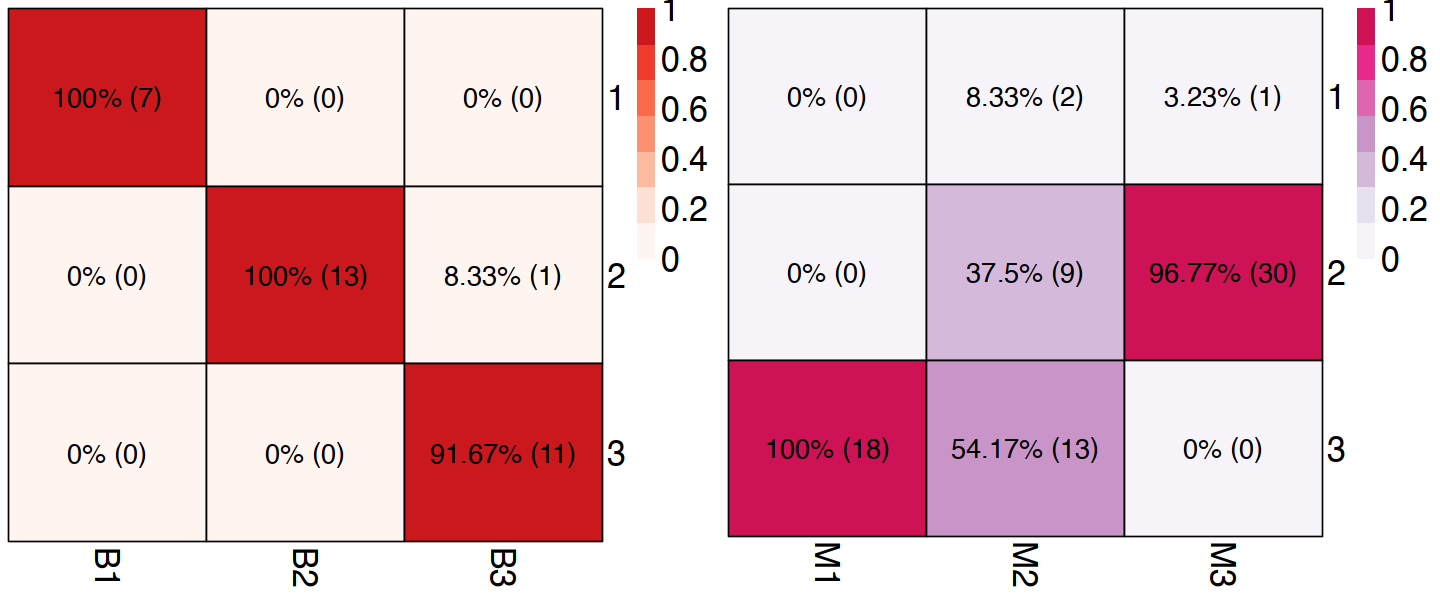

In [15]:
prettify_matrix<-function(t){
    t2 = t
    for(i in 1:ncol(t2)){t2[,i] = t2[,i]/sum(t2[,i])}
    result_matrix <- matrix(nrow = 3, ncol = 3)

    # Loop through the matrices and concatenate corresponding values
    for (i in 1:3) {
      for (j in 1:3) {
        result_matrix[i, j] <- paste0(round(t2[i, j]*100,digits=2), "% (",t[i, j],")", sep = "")
      }
    }
    return(result_matrix) 
}

norm_matrix<-function(t){
    for(i in 1:ncol(t)){t[,i]=t[,i]/sum(t[,i])}   
    return(t)
}

test_became = m_became_patients[round(nrow(m_became_patients)*.7):nrow(m_became_patients),]
t1 = table(predictions_became,meta[rownames(test_became),'cluster'])
t2 = table(predictions_miracle[rownames(m_miracle_patients)],meta[rownames(m_miracle_patients),'cluster'])

ph1 = as.ggplot(pheatmap::pheatmap(norm_matrix(t1),border_col='black',treeheight_col=0,treeheight_row=0,border_width = 10,number_color='black',col=brewer.pal(9,'Reds')[-c(8:11)],display_numbers=prettify_matrix(t1),fontsize=20,cluster_row=F,cluster_col=F,silent=T))
ph2 = as.ggplot(pheatmap::pheatmap(norm_matrix(t2),border_col='black',treeheight_col=0,treeheight_row=0,border_width = 10,number_color='black',col=brewer.pal(9,'PuRd')[-c(8:11)],display_numbers=prettify_matrix(t2),fontsize=20,cluster_row=F,cluster_col=F,silent=T))

options(repr.plot.width = 12, repr.plot.height = 5)
cowplot::plot_grid(ph1,ph2,ncol=2)

In [16]:
factor(predictions_became)

X10510 X10511 X10513 X10514 X10515 X10537 X10545 X10546 X10547 X10548 X10549 
     1      3      2      2      3      2      1      1      2      3      1 
X10550 X10551 X10552 X10569 X10597 X10605 X10606 X10607 X10608 X10609 X10610 
     2      2      2      1      3      3      3      3      3      2      2 
X10611 X10612 X10634 X10642 X10643 X10644 X10645 X10646 X10647 X10648 
     2      1      3      3      3      2      1      2      2      2 
Levels: 1 2 3

In [17]:
caret::confusionMatrix(factor(paste0('B',predictions_became)),factor(meta[rownames(test_became),'cluster']))

Confusion Matrix and Statistics

          Reference
Prediction B1 B2 B3
        B1  7  0  0
        B2  0 13  1
        B3  0  0 11

Overall Statistics
                                          
               Accuracy : 0.9688          
                 95% CI : (0.8378, 0.9992)
    No Information Rate : 0.4062          
    P-Value [Acc > NIR] : 1.447e-11       
                                          
                  Kappa : 0.9516          
                                          
 Mcnemar's Test P-Value : NA              

Statistics by Class:

                     Class: B1 Class: B2 Class: B3
Sensitivity             1.0000    1.0000    0.9167
Specificity             1.0000    0.9474    1.0000
Pos Pred Value          1.0000    0.9286    1.0000
Neg Pred Value          1.0000    1.0000    0.9524
Prevalence              0.2188    0.4062    0.3750
Detection Rate          0.2188    0.4062    0.3438
Detection Prevalence    0.2188    0.4375    0.3438
Balanced Accuracy       1.000

### Identify feature importance 

In [18]:
became = data.frame(read_xlsx('../data/BECAME1_LipidomicData_lipidesidentifiés_161lipidesCommuns.xlsx',sheet=1))
miracle = data.frame(read_xlsx('../data/MIRACLE_LipidomicData_161LipidesCommuns.xlsx',sheet=1))


In [19]:
var_importance <- data.frame(importance(rf_model_allClusters))
var_importance$lipid_id_became = became[gsub('X','',rownames(var_importance)),'Lipid.ID']
var_importance$lipid_id_miracle = miracle[gsub('X','',rownames(var_importance)),'Lipid.ID']
var_importance$lipid_class = miracle[gsub('X','',rownames(var_importance)),'Lipid.suclasses']
var_importance$modified_became_id <- with(var_importance, ifelse(duplicated(lipid_id_became) | duplicated(lipid_id_became, fromLast = TRUE), 
                                     paste(lipid_id_became, rowid(lipid_id_became, prefix = "_"), sep = "_"),
                                     lipid_id_became))
var_importance = var_importance[order(-var_importance$MeanDecreaseGini),]

Warning message in xtfrm.data.frame(x):
“cannot xtfrm data frames”


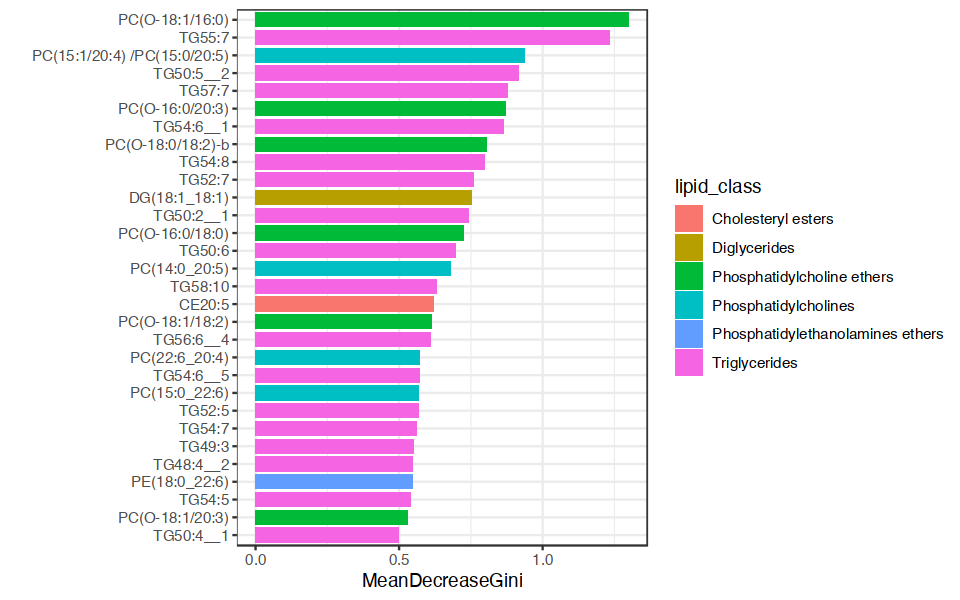

In [20]:
options(repr.plot.width = 8, repr.plot.height = 5)

var_importance$modified_became_id = factor(var_importance$modified_became_id,unique(var_importance[order(var_importance),'modified_became_id']))
ggplot(head(var_importance[order(-var_importance$MeanDecreaseGini),],30),aes(modified_became_id,MeanDecreaseGini))+
    geom_col(aes(fill=lipid_class),width=.8)+
    coord_flip()+
    theme_bw()+
    xlab('')

### Cumulative feature corruption's effect on accuracy of the model 

In [21]:
## Feature Corruption

experiment<-function(strategy='mean'){
    res = data.frame()
    
    corrupted_ordered = m_became_patients[round(nrow(m_became_patients)*.7):nrow(m_became_patients),]
    corrupted_random = m_became_patients[round(nrow(m_became_patients)*.7):nrow(m_became_patients),]
    corrupted_ordered_rev = m_became_patients[round(nrow(m_became_patients)*.7):nrow(m_became_patients),]
    random_features = sample(rownames(var_importance))
    
    ## Putting the mean 
    
    for(i in 1:161){
        if(strategy=='mean'){
            corrupted_ordered[,rownames(var_importance)[i]] = rep(mean(corrupted_ordered[,rownames(var_importance)[i]]),nrow(corrupted_ordered))
            corrupted_ordered_rev[,rownames(var_importance)[nrow(var_importance)+1-i]] = rep(mean(corrupted_ordered_rev[,rownames(var_importance)[nrow(var_importance)+1-i]]),nrow(corrupted_ordered))
            corrupted_random[,random_features[i]] = rep(mean(corrupted_random[,random_features[i]]),nrow(corrupted_ordered))
        }else{
            corrupted_ordered[,rownames(var_importance)[i]] = sample(corrupted_ordered[,rownames(var_importance)[i]])
            corrupted_ordered_rev[,rownames(var_importance)[nrow(var_importance)+1-i]] = sample(corrupted_ordered_rev[,rownames(var_importance)[nrow(var_importance)+1-i]])
            corrupted_random[,random_features[i]] = sample(corrupted_random[,random_features[i]])
        }
        
        predictions_ordered <- predict(rf_model_allClusters, corrupted_ordered, type = "response")
        predictions_ordered_rev <- predict(rf_model_allClusters, corrupted_ordered_rev, type = "response")
        predictions_random <- predict(rf_model_allClusters, corrupted_random, type = "response")
    
        accuracy_ordered <- mean(predictions_ordered == corrupted_ordered$group)
        accuracy_ordered_rev <- mean(predictions_ordered_rev == corrupted_ordered_rev$group)
        accuracy_random <- mean(predictions_random == corrupted_random$group)
        
        res=rbind(res,c(accuracy_ordered,i,'ordered_best',strategy),c(accuracy_ordered_rev,i,'ordered_worst',strategy),c(accuracy_random,i,'random',strategy))
    }
    colnames(res) = c('accuracy','nfeatures','group','strategy')
    return(res)
}

res = rbind(experiment(strategy='mean'),
            experiment(strategy='permute'))


Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


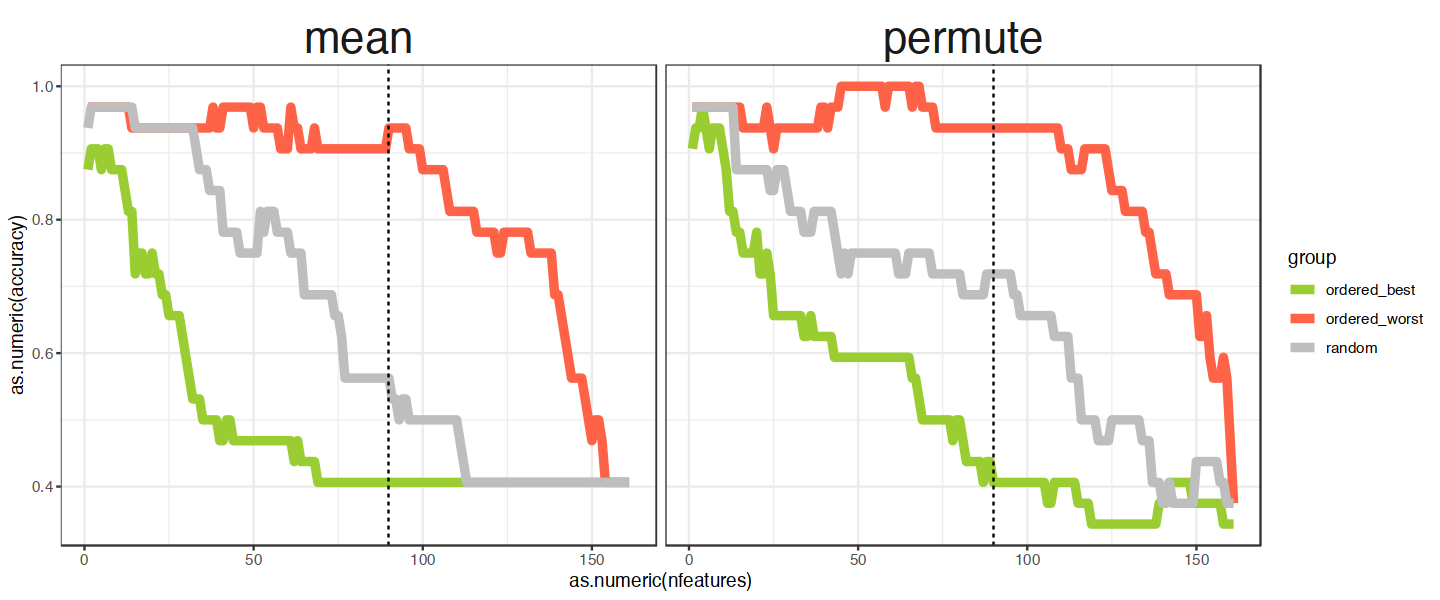

In [22]:
options(repr.plot.width = 12, repr.plot.height = 5)

ggplot(res,aes(as.numeric(nfeatures),as.numeric(accuracy)))+
    geom_line(aes(col=group),size=2)+
    theme_bw()+
    facet_wrap(~strategy)+
    geom_vline(xintercept=90,linetype='dashed')+
    scale_color_manual(values=c('olivedrab3','tomato','grey'))+
    theme(strip.background=element_blank(),strip.text=element_text(size=26))

In [23]:
head(var_importance)

,MeanDecreaseGini,lipid_id_became,lipid_id_miracle,lipid_class,modified_became_id
,<dbl>,<chr>,<chr>,<chr>,<fct>
X51,1.2990046,PC(O-18:1/16:0),PC(O-18:0/20:4),Phosphatidylcholine ethers,PC(O-18:1/16:0)
X146,1.2330056,TG55:7,TG55:7,Triglycerides,TG55:7
X64,0.9376811,PC(15:1/20:4) /PC(15:0/20:5),PC(15:0/20:5),Phosphatidylcholines,PC(15:1/20:4) /PC(15:0/20:5)
X127,0.9159059,TG50:5,TG50:6,Triglycerides,TG50:5__2
X154,0.8780028,TG57:7,TG57:7,Triglycerides,TG57:7
X43,0.8719292,PC(O-16:0/20:3),PC(O-16:0/18:2),Phosphatidylcholine ethers,PC(O-16:0/20:3)


In [24]:
write.table(var_importance,'../data/var_importance.all_clusters.csv',quote=F,sep=',')

In [25]:
predictions <- predict(rf_model_allClusters, scaled_df, type = "response")

In [26]:
meta$preds = paste0('C',predictions[rownames(meta)])

In [27]:
write.table(meta,'../data/merged_dataset_meta.csv',sep=',',quote=F)

In [28]:
scaled_df_patients = scaled_df[rownames(subset(meta,group=='HFpEF')),]
pca = prcomp(scaled_df_patients)$x 

meta_patients = subset(meta,group=='HFpEF')
meta_patients$PC1 = pca[rownames(meta_patients),1]
meta_patients$PC2 = pca[rownames(meta_patients),2]

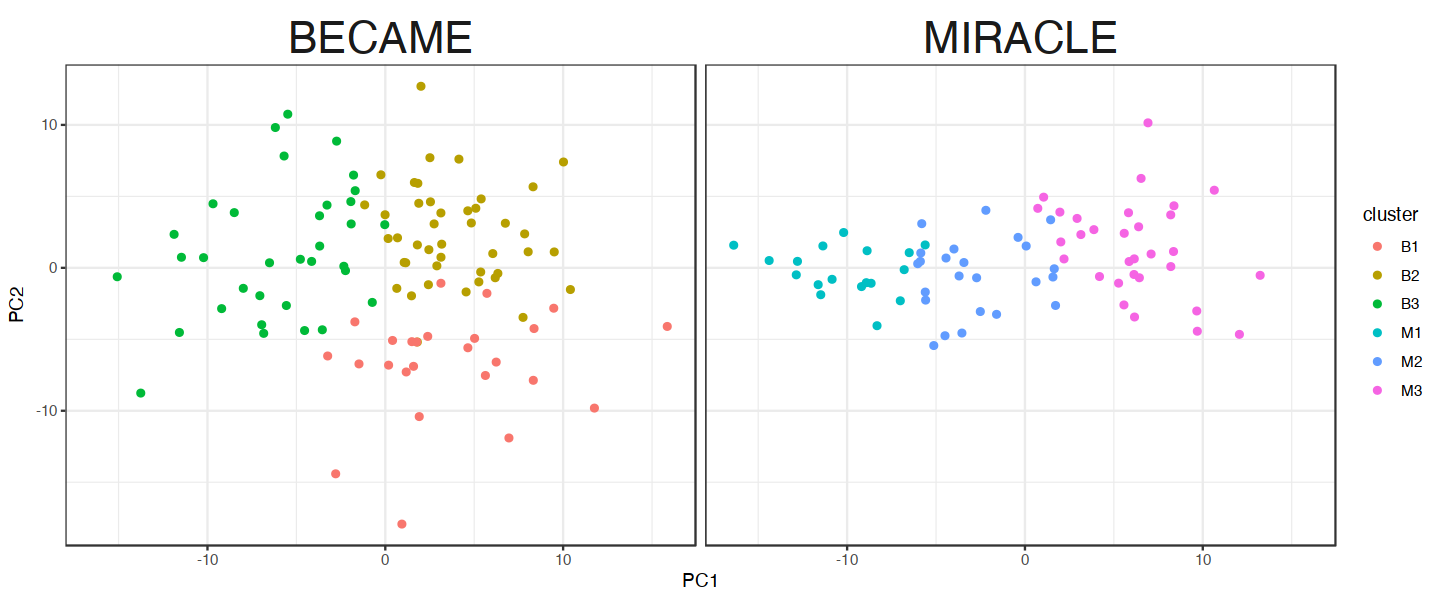

In [29]:
options(repr.plot.width = 12, repr.plot.height = 5)

ggplot(meta_patients,aes(PC1,PC2,col=cluster))+geom_point()+facet_grid(~cohort)+theme_bw()+
    theme(strip.background=element_blank(),strip.text=element_text(size=26))

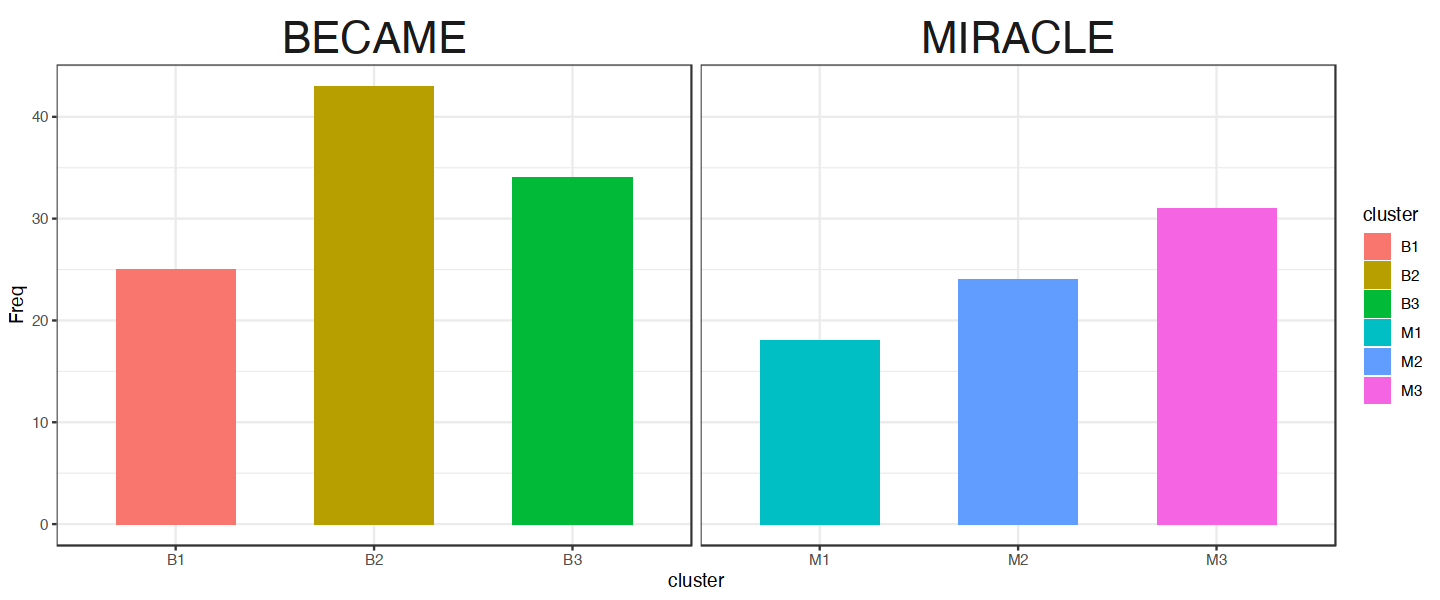

In [49]:
t = table(meta_patients[,c('cohort','cluster')])
t=data.frame(t)
t = t[which(t$Freq>0),]
ggplot(t,aes(cluster,Freq,fill=cluster))+geom_col(width=.6)+facet_wrap(~cohort,scales='free_x')+theme_bw()+
    theme(strip.background=element_blank(),strip.text=element_text(size=26))

In [30]:
predictions <- predict(rf_model_allClusters, scaled_df_patients, type = "response")

In [32]:
meta_patients$predictions = paste0('C',predictions[rownames(meta_patients)])

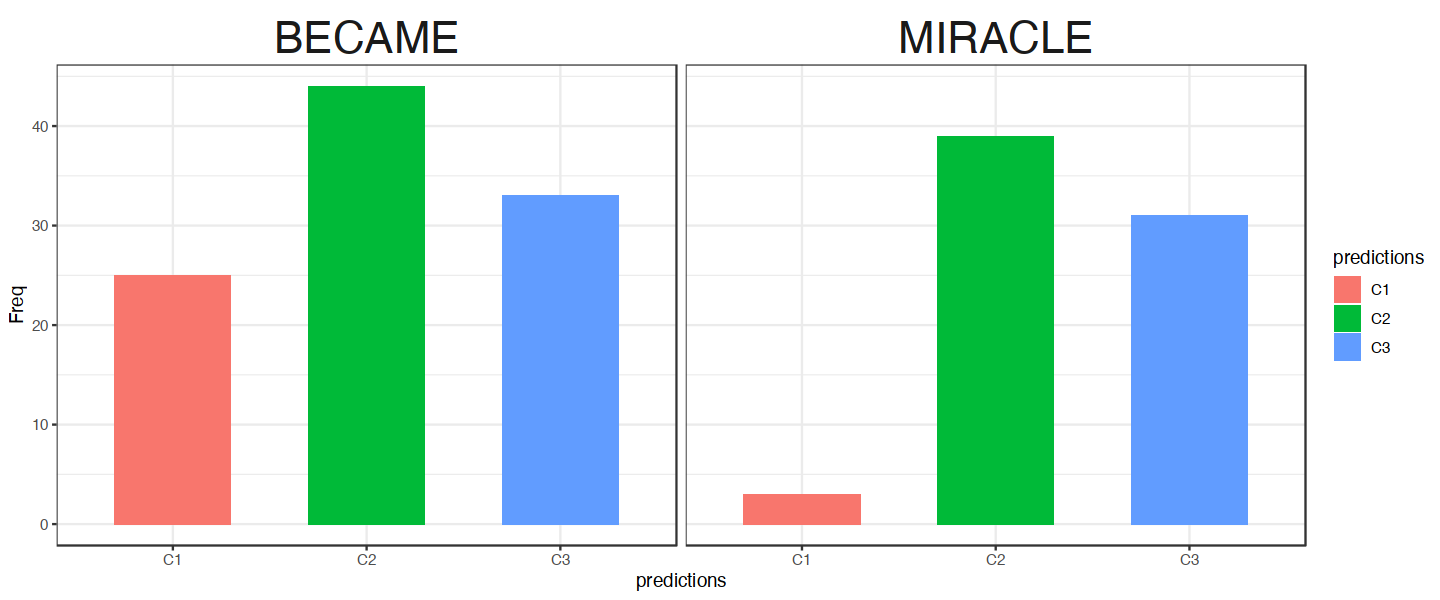

In [51]:
t = table(meta_patients[,c('cohort','predictions')])
t=data.frame(t)
t = t[which(t$Freq>0),]
ggplot(t,aes(predictions,Freq,fill=predictions))+geom_col(width=.6)+facet_wrap(~cohort,scales='free_x')+theme_bw()+
    theme(strip.background=element_blank(),strip.text=element_text(size=26))

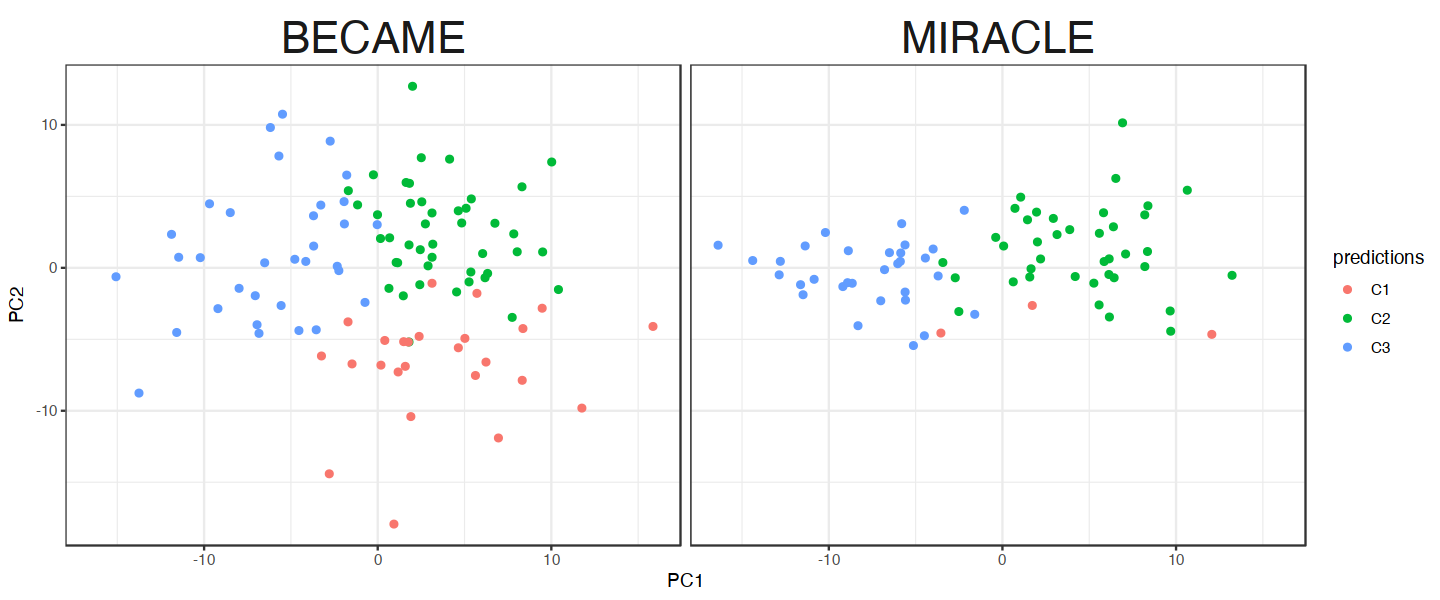

In [33]:
ggplot(meta_patients,aes(PC1,PC2,col=predictions))+geom_point()+facet_grid(~cohort)+theme_bw()+
    theme(strip.background=element_blank(),strip.text=element_text(size=26))

In [38]:
table(meta[,c('group','cohort')])

         cohort
group     BECAME MIRACLE
  CONTROL     72     102
  HFpEF      102      73